# ASSIGNMENT_3

(Capstone Project_3)

## **Netflix_Data________[ E.D.A ]**

(Date : 15/Apr/2026)

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. DATA EXPLORATION

In [49]:
df = pd.read_csv('netflix_titles.csv')
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [50]:
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nDataset Info:")
df.info()

Shape of dataset: (8807, 12)

Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release

## 2. DATA CLEANING

In [80]:
# --- Missing values ---
print("Missing values per column:\n", df.isnull().sum())
print("\nMissing value percentage:\n", (df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
 show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
duration              0
listed_in             0
description           0
date_added_parsed    10
year_added           10
month_added          10
dtype: int64

Missing value percentage:
 show_id              0.00
type                 0.00
title                0.00
director             0.00
cast                 0.00
country              0.00
date_added           0.00
release_year         0.00
rating               0.00
duration             0.00
listed_in            0.00
description          0.00
date_added_parsed    0.11
year_added           0.11
month_added          0.11
dtype: float64


In [82]:
# Fill missing values

df.fillna({'director': 'Unknown'}, inplace=True)
df.fillna({'cast': 'Unknown'}, inplace=True)
df.fillna({'country': 'Unknown'}, inplace=True)
df.fillna({'date_added': 'Unknown'}, inplace=True)
df.fillna({'rating': 'Unknown'}, inplace=True)
df.fillna({'duration': 'Unknown'}, inplace=True)

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
duration              0
listed_in             0
description           0
date_added_parsed    10
year_added           10
month_added          10
dtype: int64


In [83]:
# --- Duplicates ---

print("Number of duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Rows after removing duplicates:", len(df))

Number of duplicate rows: 0
Rows after removing duplicates: 8807


In [54]:
# --- Strip whitespace ---
df['title'] = df['title'].str.strip()
df['type']  = df['type'].str.strip()

In [73]:
# --- Parse date_added ---
df['date_added'] = df['date_added'].str.strip()
df['date_added_parsed'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df['year_added']  = df['date_added_parsed'].dt.year
df['month_added'] = df['date_added_parsed'].dt.month

print("Sample cleaned data:\n", df[['title', 'type', 'rating', 'year_added']].head())

Sample cleaned data:
                    title     type rating  year_added
0   Dick Johnson Is Dead    Movie  PG-13      2021.0
1          Blood & Water  TV Show  TV-MA      2021.0
2              Ganglands  TV Show  TV-MA      2021.0
3  Jailbirds New Orleans  TV Show  TV-MA      2021.0
4           Kota Factory  TV Show  TV-MA      2021.0


## 3. DESCRIPTIVE STATISTICS

In [84]:
print("Basic statistics for release_year:\n", df['release_year'].describe())
print("\nMean release year:",   round(df['release_year'].mean(), 2))
print("Median release year:", df['release_year'].median())
print("Mode release year:",   df['release_year'].mode()[0])
print("Std release year:",    round(df['release_year'].std(), 2))
print("Range release year:",  df['release_year'].max() - df['release_year'].min())

# Movie duration (numeric)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_mins'] = movies['duration'].str.replace(' min', '', regex=False)
movies['duration_mins'] = pd.to_numeric(movies['duration_mins'], errors='coerce')

print("\nMovie duration (minutes) statistics:\n", movies['duration_mins'].describe())
print("Mean duration:",   round(movies['duration_mins'].mean(), 2))
print("Median duration:", movies['duration_mins'].median())
print("Mode duration:",   movies['duration_mins'].mode()[0])
print("Std duration:",    round(movies['duration_mins'].std(), 2))

# TV Show seasons
shows = df[df['type'] == 'TV Show'].copy()
shows['seasons'] = shows['duration'].str.replace(' Season.*', '', regex=True)
shows['seasons'] = pd.to_numeric(shows['seasons'], errors='coerce')

print("\nTV Show seasons statistics:\n", shows['seasons'].describe())

Basic statistics for release_year:
 count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

Mean release year: 2014.18
Median release year: 2017.0
Mode release year: 2018
Std release year: 8.82
Range release year: 96

Movie duration (minutes) statistics:
 count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_mins, dtype: float64
Mean duration: 99.58
Median duration: 98.0
Mode duration: 90.0
Std duration: 28.29

TV Show seasons statistics:
 count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


## 4. DATA VISUALIZATION – PART 1: Genre Distribution

Top 15 genres:
                    Genre  Count
    International Movies   2752
                  Dramas   2427
                Comedies   1674
  International TV Shows   1351
           Documentaries    869
      Action & Adventure    859
               TV Dramas    763
      Independent Movies    756
Children & Family Movies    641
         Romantic Movies    616
             TV Comedies    581
               Thrillers    577
          Crime TV Shows    470
                Kids' TV    451
              Docuseries    395


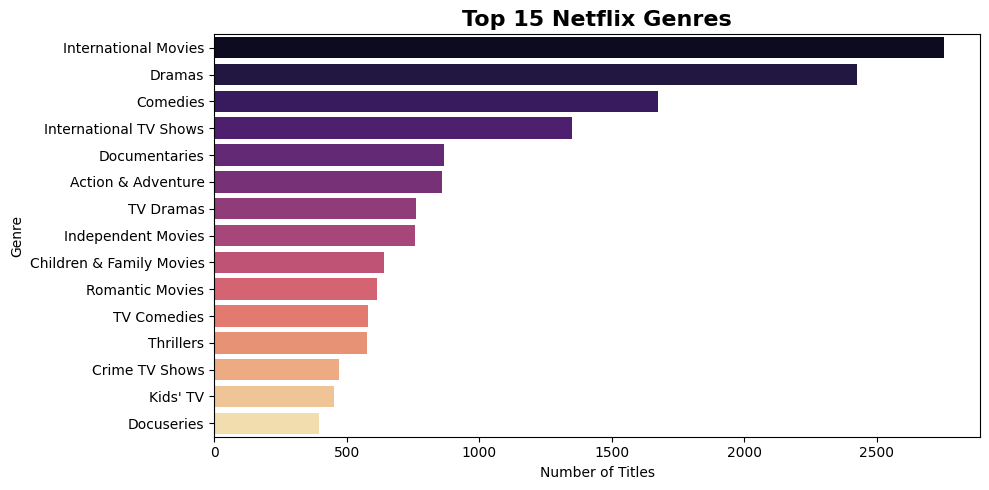

In [85]:
all_genres = []
for genres in df['listed_in'].dropna():
    for g in genres.split(','):
        all_genres.append(g.strip())

genre_df = pd.Series(all_genres).value_counts().head(15).reset_index()
genre_df.columns = ['Genre', 'Count']

print("Top 15 genres:\n", genre_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_df, x='Count', y='Genre', hue='Genre', palette='magma', legend=False)
plt.title('Top 15 Netflix Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

## 5. DATA VISUALIZATION – PART 2: Release Year Distribution

Content count by release year (last 10):
 release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


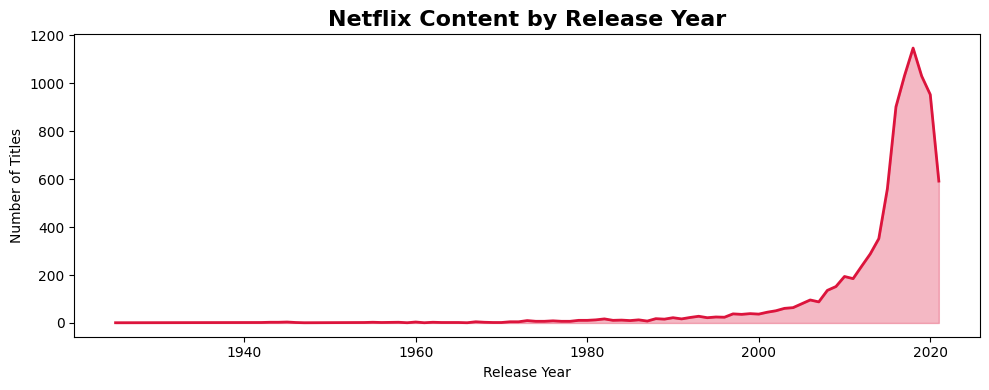

In [86]:
year_counts = df['release_year'].value_counts().sort_index()
print("Content count by release year (last 10):\n", year_counts.tail(10))

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values, color='crimson', linewidth=2)
plt.fill_between(year_counts.index, year_counts.values, alpha=0.3, color='crimson')
plt.title('Netflix Content by Release Year', fontsize=16, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('release_year_distribution.png', dpi=150)
plt.show()

## 6. DATA VISUALIZATION – PART 3: Geographical Distribution

Top 20 countries by content:
        Country  Count
 United States   3690
         India   1046
United Kingdom    806
        Canada    445
        France    393
         Japan    318
         Spain    232
   South Korea    231
       Germany    226
        Mexico    169
         China    162
     Australia    160
         Egypt    117
        Turkey    113
     Hong Kong    105
       Nigeria    103
         Italy    100
        Brazil     97
     Argentina     91
     Indonesia     90


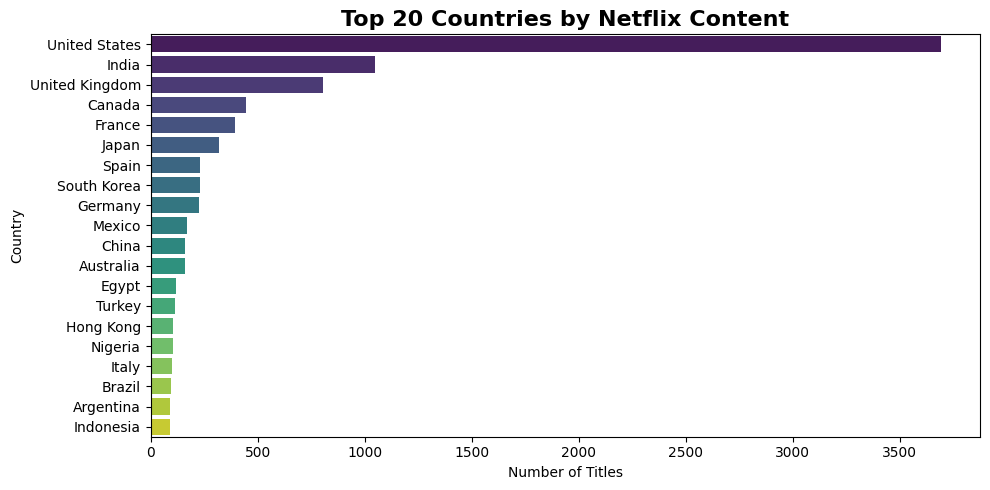

In [87]:
all_countries = []
for entry in df['country'].dropna():
    for c in entry.split(','):
        c = c.strip()
        if c not in ('', 'Unknown'):
            all_countries.append(c)

country_df = pd.Series(all_countries).value_counts().head(20).reset_index()
country_df.columns = ['Country', 'Count']

print("Top 20 countries by content:\n", country_df.to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(data=country_df, x='Count', y='Country', hue='Country', palette='viridis', legend=False)
plt.title('Top 20 Countries by Netflix Content', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('geographical_distribution.png', dpi=150)
plt.show()

## 7. TIME SERIES ANALYSIS

Yearly additions by type:
  year_added  Movie  TV Show
       2008      1        1
       2009      2        0
       2010      1        0
       2011     13        0
       2012      3        0
       2013      6        5
       2014     19        5
       2015     56       26
       2016    253      176
       2017    839      349
       2018   1237      412
       2019   1424      592
       2020   1284      595
       2021    993      505


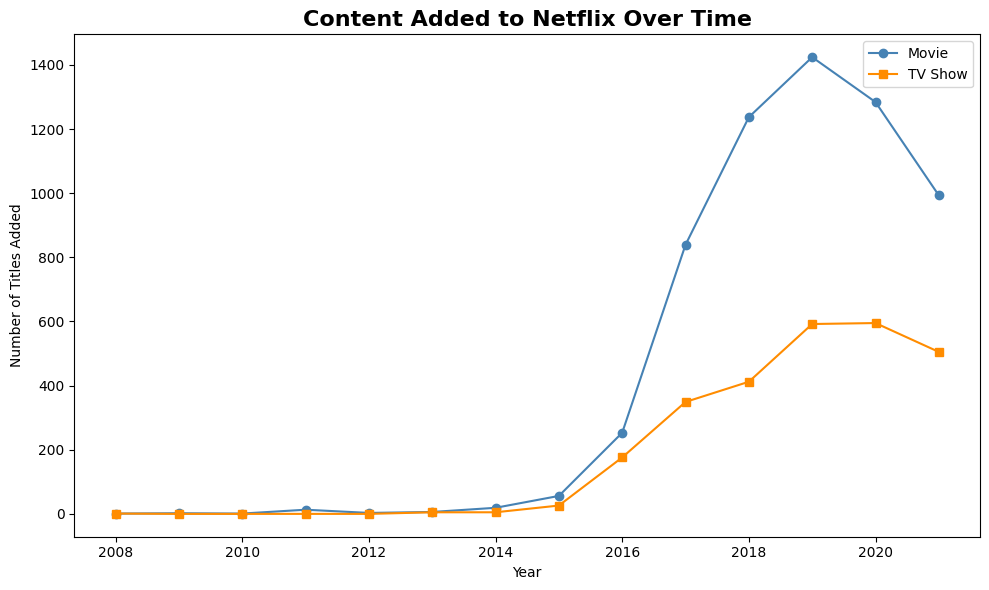

In [88]:
time_df = df[df['year_added'].notna()].copy()
time_df['year_added'] = time_df['year_added'].astype(int)

yearly = time_df.groupby(['year_added', 'type']).size().unstack(fill_value=0).reset_index()
print("Yearly additions by type:\n", yearly.to_string(index=False))

plt.figure(figsize=(10, 6))
if 'Movie' in yearly.columns:
    plt.plot(yearly['year_added'], yearly['Movie'],    marker='o', label='Movie',   color='steelblue')
if 'TV Show' in yearly.columns:
    plt.plot(yearly['year_added'], yearly['TV Show'],  marker='s', label='TV Show', color='darkorange')
plt.title('Content Added to Netflix Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend()
plt.tight_layout()
plt.savefig('time_series_analysis.png', dpi=150)
plt.show()

## 8. CONTENT ANALYSIS – PART 1: Rating Distribution

Rating distribution:
   Rating  Count
   TV-MA   3207
   TV-14   2160
   TV-PG    863
       R    799
   PG-13    490
   TV-Y7    334
    TV-Y    307
      PG    287
    TV-G    220
      NR     80
       G     41
TV-Y7-FV      6
 Unknown      4
   NC-17      3
      UR      3
  66 min      1
  74 min      1
  84 min      1


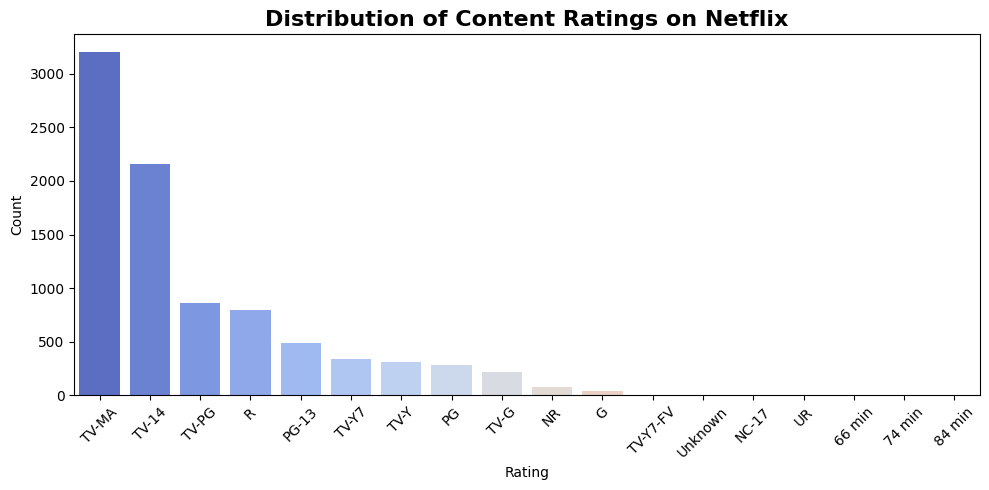

In [89]:
rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['Rating', 'Count']
print("Rating distribution:\n", rating_counts.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=rating_counts, x='Rating', y='Count', hue='Rating', palette='coolwarm', legend=False)
plt.title('Distribution of Content Ratings on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

## 9. CONTENT ANALYSIS – PART 2: Duration / Episode Length

Movie duration stats (minutes):
 count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_mins, dtype: float64

TV Show season stats:
 count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


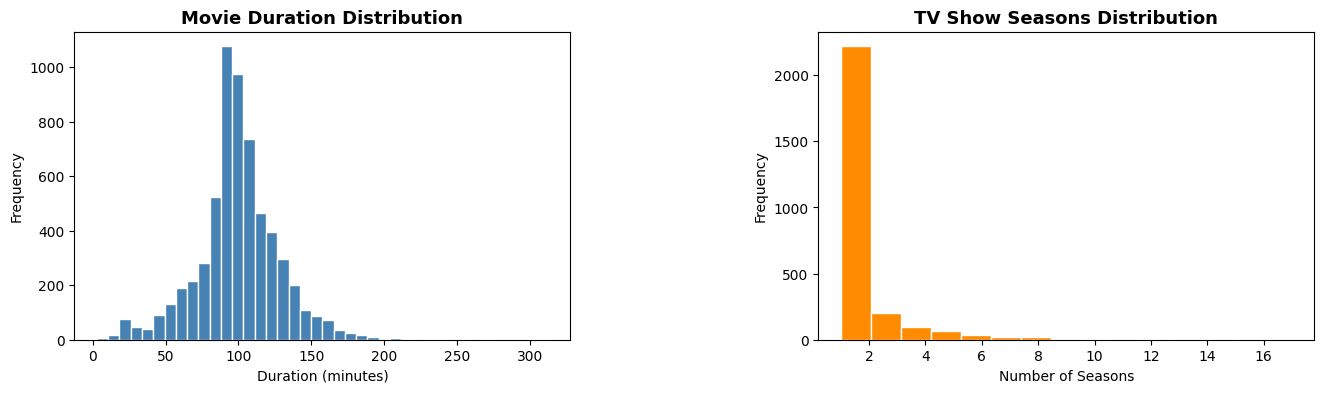

In [104]:
print("Movie duration stats (minutes):\n", movies['duration_mins'].describe())
print("\nTV Show season stats:\n", shows['seasons'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(movies['duration_mins'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Movie Duration Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Frequency')

axes[1].hist(shows['seasons'].dropna(), bins=15, color='darkorange', edgecolor='white')
axes[1].set_title('TV Show Seasons Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Frequency')

plt.subplots_adjust(wspace=0.5)     # To adjust the gap between two subplot
plt.savefig('duration_distribution.png', dpi=150)
plt.show()

## 10. TOP LISTS

In [63]:
print("Top 10 most recent Movies added:\n",
      df[df['type'] == 'Movie'][['title', 'release_year', 'rating', 'duration']]
        .sort_values('release_year', ascending=False).head(10).to_string(index=False))

print("\nTop 10 most recent TV Shows added:\n",
      df[df['type'] == 'TV Show'][['title', 'release_year', 'rating', 'duration']]
        .sort_values('release_year', ascending=False).head(10).to_string(index=False))

print("\nTop 10 directors by content count:\n",
      df[df['director'] != 'Unknown']['director'].value_counts().head(10))

Top 10 most recent Movies added:
                          title  release_year rating duration
        My Heroes Were Cowboys          2021     PG   23 min
                The Stronghold          2021  TV-MA  105 min
The Father Who Moves Mountains          2021  TV-MA  110 min
               Ankahi Kahaniya          2021  TV-14  111 min
                    Nightbooks          2021  TV-PG  103 min
                    Schumacher          2021  TV-14  113 min
   A StoryBots Space Adventure          2021   TV-Y   13 min
                       YES DAY          2021     PG   90 min
                   Paper Lives          2021  TV-MA   97 min
                   C/O Kaadhal          2021  TV-14  131 min

Top 10 most recent TV Shows added:
                         title  release_year rating  duration
           Metal Shop Masters          2021  TV-MA  1 Season
                Midnight Mass          2021  TV-MA  1 Season
The Great British Baking Show          2021  TV-14 9 Seasons
              

## 11. GENRE TRENDS OVER TIME

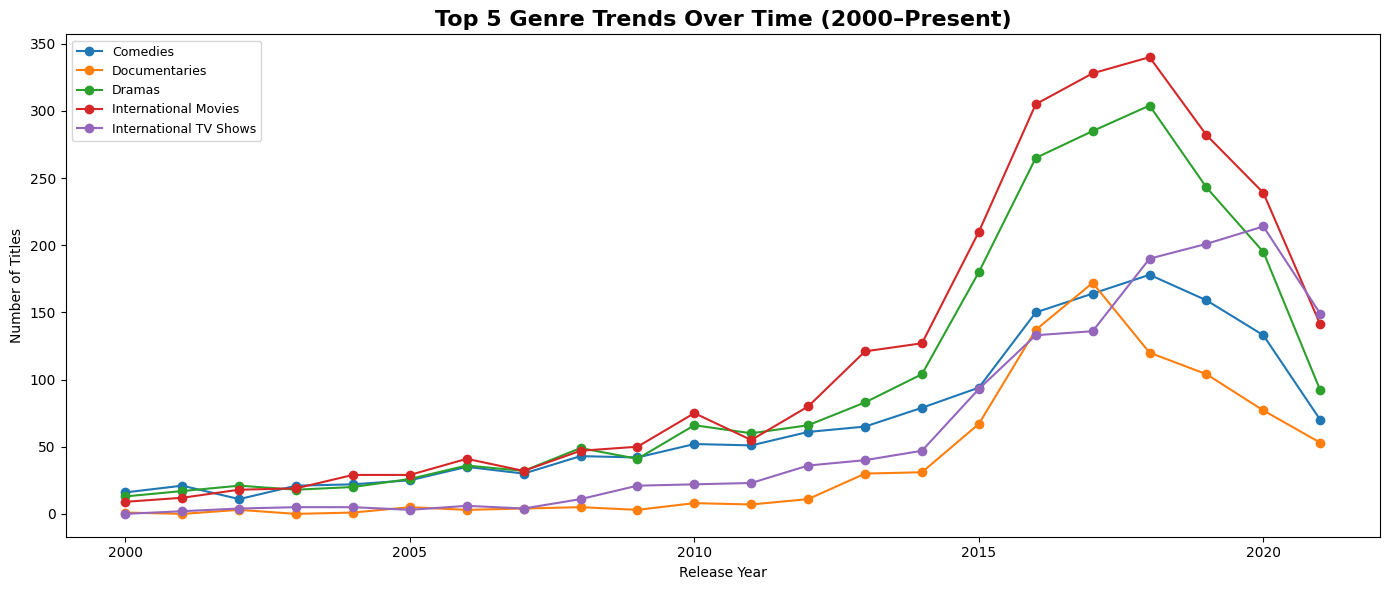

In [108]:
genre_year_rows = []
for _, row in df.iterrows():
    if pd.notna(row['listed_in']) and pd.notna(row['release_year']):
        for g in row['listed_in'].split(','):
            genre_year_rows.append({'Genre': g.strip(), 'release_year': int(row['release_year'])})

genre_year_df = pd.DataFrame(genre_year_rows)

top5_genres = genre_df['Genre'].head(5).tolist()
filtered = genre_year_df[genre_year_df['Genre'].isin(top5_genres)]
pivot = filtered.groupby(['release_year', 'Genre']).size().unstack(fill_value=0)
pivot_recent = pivot[pivot.index >= 2000]

plt.figure(figsize=(14, 6))
for col in pivot_recent.columns:
    plt.plot(pivot_recent.index, pivot_recent[col], marker='o', label=col)
plt.title('Top 5 Genre Trends Over Time (2000–Present)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('genre_trends.png', dpi=150)
plt.show()

## 12. GEOGRAPHICAL ANALYSIS (Pie Chart)

Top 10 countries content share:
        Country  Count
 United States   3690
         India   1046
United Kingdom    806
        Canada    445
        France    393
         Japan    318
         Spain    232
   South Korea    231
       Germany    226
        Mexico    169


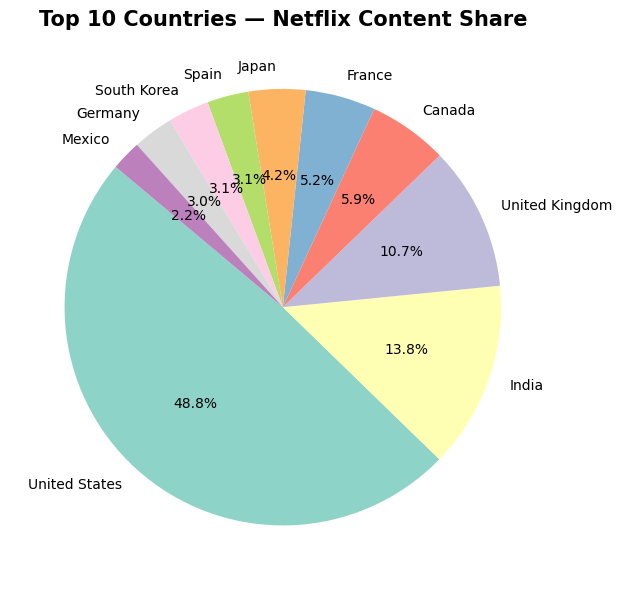

In [124]:
top10_countries = country_df.head(10)
print("Top 10 countries content share:\n", top10_countries.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.pie(top10_countries['Count'], labels=top10_countries['Country'],
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3', 10))
plt.title('Top 10 Countries — Netflix Content Share', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('country_pie.png', dpi=150)
plt.show()

## 13. CORRELATION ANALYSIS

Correlation matrix (release_year vs duration_mins):
                release_year  duration_mins
release_year       1.000000      -0.206285
duration_mins     -0.206285       1.000000


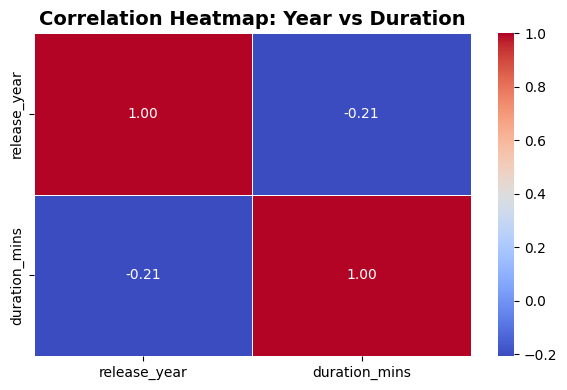

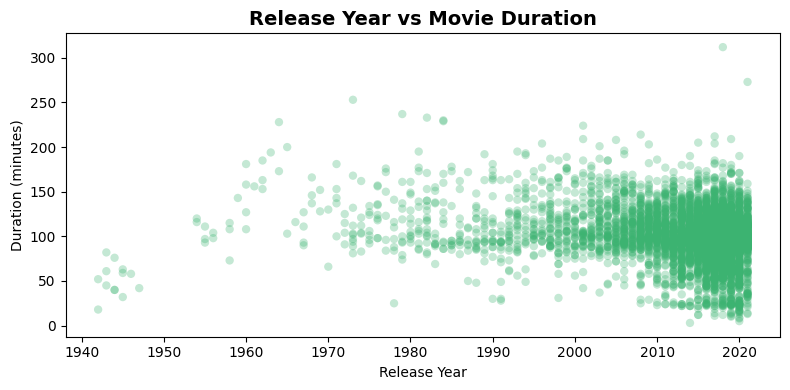

In [136]:
corr_df = movies[['release_year', 'duration_mins']].dropna()
correlation = corr_df.corr()
print("Correlation matrix (release_year vs duration_mins):\n", correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Year vs Duration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\n")
plt.figure(figsize=(8, 4))
plt.scatter(corr_df['release_year'], corr_df['duration_mins'],
            alpha=0.3, color='mediumseagreen', edgecolors='none')
plt.title('Release Year vs Movie Duration', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.savefig('scatter_year_duration.png', dpi=150)
plt.show()

## 14. AUDIENCE ENGAGEMENT – PART 1: Sentiment placeholder

In [139]:
print("Note: User review / sentiment data not present in this dataset.")
print("Sentiment analysis placeholder complete.")

Note: User review / sentiment data not present in this dataset.
Sentiment analysis placeholder complete.


## 15. AUDIENCE ENGAGEMENT – PART 2: Views / Watch Time

In [68]:
print("Note: View count / watch-time metrics are not publicly available in this dataset.")
print("These would be pulled from Netflix's internal analytics or third-party APIs.")
print("Proxy analysis: content additions per year as a popularity indicator.")

additions_by_year = df.groupby('year_added').size().dropna()
print("Titles added per year:\n", additions_by_year.dropna().astype(int))

Note: View count / watch-time metrics are not publicly available in this dataset.
These would be pulled from Netflix's internal analytics or third-party APIs.
Proxy analysis: content additions per year as a popularity indicator.
Titles added per year:
 year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64


## 16. CONTENT VARIETY

Unique genres: 15
Unique countries: 20
Unique content ratings: 18
Unique content types: 2
Total unique titles: 8806


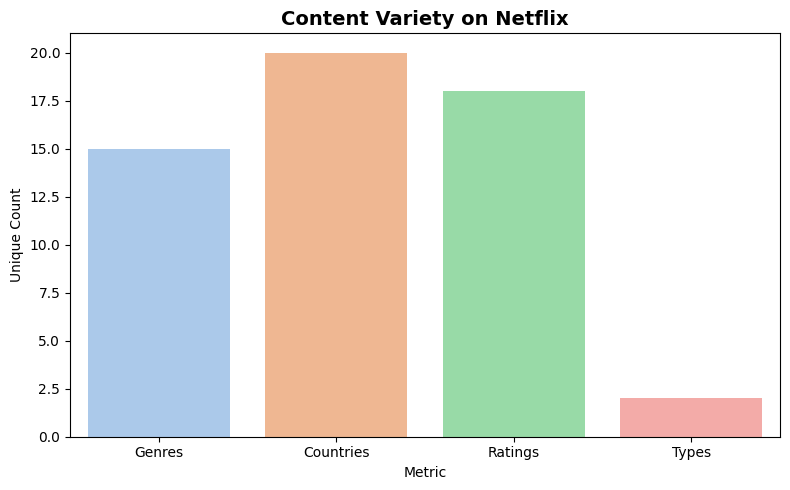

In [116]:
unique_genres = len(genre_df)
unique_countries = len(country_df)
unique_ratings = df['rating'].nunique()
unique_types = df['type'].nunique()

print("Unique genres:", unique_genres)
print("Unique countries:", unique_countries)
print("Unique content ratings:", unique_ratings)
print("Unique content types:", unique_types)
print("Total unique titles:", df['title'].nunique())

variety_data  = {'Metric': ['Genres', 'Countries', 'Ratings', 'Types'],
                 'Count':  [unique_genres, unique_countries, unique_ratings, unique_types]}
variety_df = pd.DataFrame(variety_data)

plt.figure(figsize=(8, 5))
sns.barplot(data=variety_df, x='Metric', y='Count', hue='Metric', palette='pastel', legend=False)
plt.title('Content Variety on Netflix', fontsize=14, fontweight='bold')
plt.ylabel('Unique Count')
plt.tight_layout()
plt.savefig('content_variety.png', dpi=150)
plt.show()

## 17. LANGUAGE ANALYSIS (proxy via country)

Note: No explicit language column in this dataset.
Using country as a proxy for primary language:
Content by inferred language:
 language_proxy
English           3839
Other             1945
Hindi/Regional    1008
Unknown            831
Spanish            315
Japanese           259
French             212
Korean             211
German             103
Portuguese          84
Name: count, dtype: int64


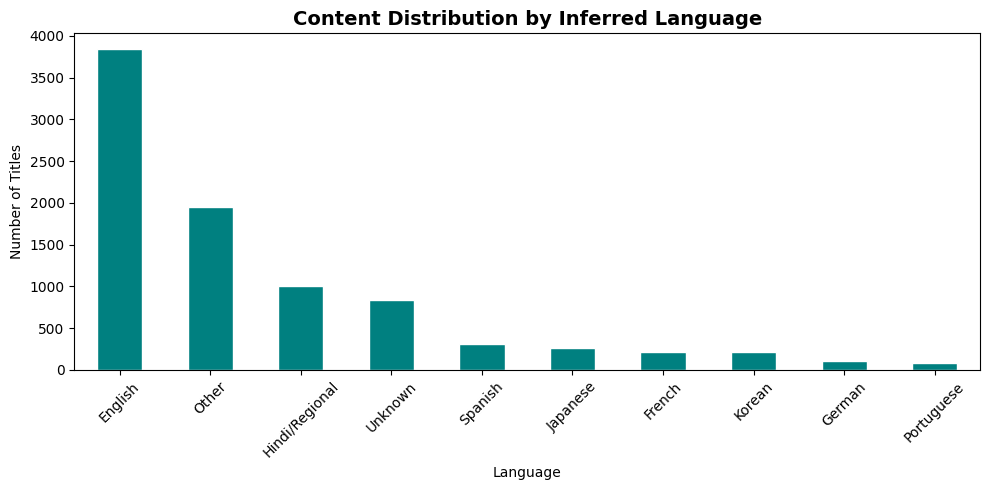

In [118]:
print("Note: No explicit language column in this dataset.")
print("Using country as a proxy for primary language:")

country_language_map = {
    'United States': 'English', 'United Kingdom': 'English',
    'India': 'Hindi/Regional', 'Japan': 'Japanese',
    'South Korea': 'Korean', 'France': 'French',
    'Spain': 'Spanish', 'Germany': 'German',
    'Mexico': 'Spanish', 'Brazil': 'Portuguese'
}

df['language_proxy'] = df['country'].apply(
    lambda x: country_language_map.get(x.split(',')[0].strip(), 'Other') if x != 'Unknown' else 'Unknown'
)

lang_counts = df['language_proxy'].value_counts()
print("Content by inferred language:\n", lang_counts)

plt.figure(figsize=(10, 5))
lang_counts.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Content Distribution by Inferred Language', fontsize=14, fontweight='bold')
plt.xlabel('Language')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('language_distribution.png', dpi=150)
plt.show()

## 18. CONTENT EVOLUTION OVER TIME

Average movie duration by year (from 1990):
  release_year  avg_duration
         2007    113.229730
         2008    106.238938
         2009    108.949153
         2010    104.457516
         2011    102.868966
         2012    100.757225
         2013     98.048889
         2014    100.261364
         2015     99.513854
         2016     95.360182
         2017     95.535248
         2018     96.185137
         2019     93.466035
         2020     92.141199
         2021     96.444043


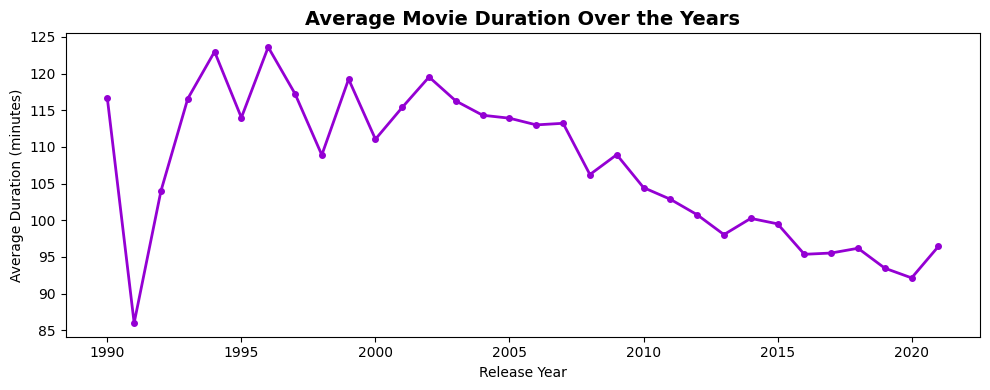

Duration evolution chart.




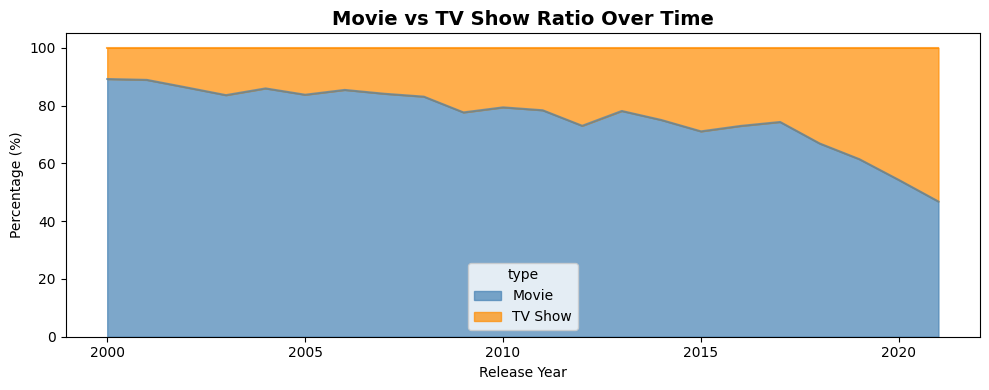

Type ratio chart.


In [122]:
evolution = movies.groupby('release_year')['duration_mins'].mean().reset_index()
evolution.columns = ['release_year', 'avg_duration']
evolution = evolution[evolution['release_year'] >= 1990]

print("Average movie duration by year (from 1990):\n", evolution.tail(15).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(evolution['release_year'], evolution['avg_duration'],
         color='darkviolet', linewidth=2, marker='o', markersize=4)
plt.title('Average Movie Duration Over the Years', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes)')
plt.tight_layout()
plt.savefig('duration_evolution.png', dpi=150)
plt.show()
print("Duration evolution chart.")

print("\n")
# Type ratio over time
type_year = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
type_year = type_year[type_year.index >= 2000]
type_year_pct = type_year.div(type_year.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 4))
type_year_pct.plot(kind='area', stacked=True, alpha=0.7,
                   color=['steelblue', 'darkorange'], ax=plt.gca())
plt.title('Movie vs TV Show Ratio Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.savefig('type_ratio_over_time.png', dpi=150)
plt.show()
print("Type ratio chart.")

## 19. USER PREFERENCES

Most common genres overall:
                    Genre  Count
    International Movies   2752
                  Dramas   2427
                Comedies   1674
  International TV Shows   1351
           Documentaries    869
      Action & Adventure    859
               TV Dramas    763
      Independent Movies    756
Children & Family Movies    641
         Romantic Movies    616

Top movie genres:
 International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Top TV Show genres:
 International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
Name: count, dtype: int64


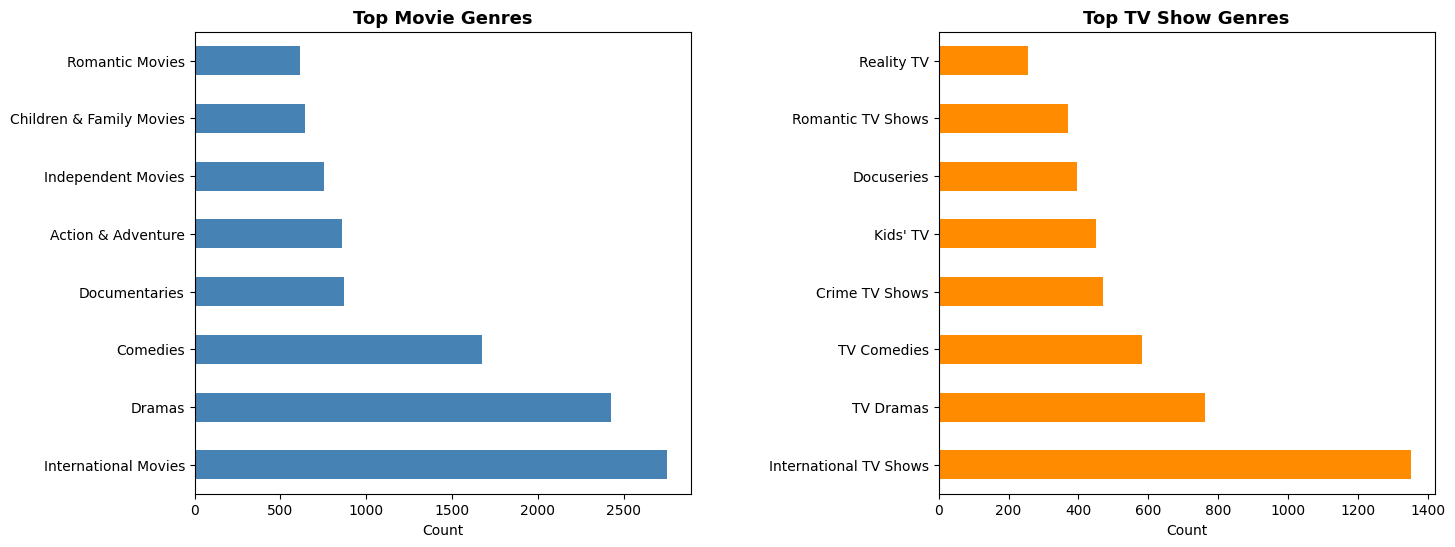

User preferences chart.


In [134]:
print("Most common genres overall:\n", genre_df.head(10).to_string(index=False))

movie_genres, show_genres = [], []
for _, row in df.iterrows():
    if pd.notna(row['listed_in']):
        for g in row['listed_in'].split(','):
            g = g.strip()
            if row['type'] == 'Movie':
                movie_genres.append(g)
            elif row['type'] == 'TV Show':
                show_genres.append(g)

top_movie_genres = pd.Series(movie_genres).value_counts().head(8)
top_show_genres  = pd.Series(show_genres).value_counts().head(8)

print("\nTop movie genres:\n", top_movie_genres)
print("\nTop TV Show genres:\n", top_show_genres)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_movie_genres.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top Movie Genres', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

top_show_genres.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top TV Show Genres', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.subplots_adjust(wspace=0.5)
plt.savefig('user_preferences.png', dpi=150)
plt.show()
print("User preferences chart.")

## 20. CONCLUSIONS AND RECOMMENDATIONS

In [135]:
print("\n--- KEY FINDINGS ---")
print("1. Total titles in dataset:", len(df))
print("2. Movies:", len(df[df['type'] == 'Movie']), " | TV Shows:", len(df[df['type'] == 'TV Show']))
print("3. Most common genre:", genre_df.iloc[0]['Genre'], "with", genre_df.iloc[0]['Count'], "titles")
print("4. Top producing country:", country_df.iloc[0]['Country'], "with", country_df.iloc[0]['Count'], "titles")
print("5. Average movie duration (mins):", round(movies['duration_mins'].mean(), 1))
print("6. Most common rating:", df['rating'].value_counts().index[0])
print("7. Year with most content added:", int(df['year_added'].value_counts().index[0]) if df['year_added'].notna().any() else "N/A")
print("8. Unique genres available:", unique_genres)
print("9. Content spans release years from", df['release_year'].min(), "to", df['release_year'].max())

print("\n--- RECOMMENDATIONS ---")
print("1. Invest more in International content — India, South Korea, and Japan show high output.")
print("2. Dramas and Comedies dominate; diversifying into niche genres may attract new users.")
print("3. TV Shows with multiple seasons drive long-term engagement — expand originals.")
print("4. Content rated TV-MA and TV-14 is most prevalent; add family-friendly content for broader reach.")
print("5. Recent years show surge in content additions — maintain momentum with quality curation.")
print("6. Average movie duration is stable around 90-100 mins; shorter content may suit mobile users.")
print("7. Genre trend data shows Documentary and Stand-Up growing — invest in non-fiction originals.")


--- KEY FINDINGS ---
1. Total titles in dataset: 8807
2. Movies: 6131  | TV Shows: 2676
3. Most common genre: International Movies with 2752 titles
4. Top producing country: United States with 3690 titles
5. Average movie duration (mins): 99.6
6. Most common rating: TV-MA
7. Year with most content added: 2019
8. Unique genres available: 15
9. Content spans release years from 1925 to 2021

--- RECOMMENDATIONS ---
1. Invest more in International content — India, South Korea, and Japan show high output.
2. Dramas and Comedies dominate; diversifying into niche genres may attract new users.
3. TV Shows with multiple seasons drive long-term engagement — expand originals.
4. Content rated TV-MA and TV-14 is most prevalent; add family-friendly content for broader reach.
5. Recent years show surge in content additions — maintain momentum with quality curation.
6. Average movie duration is stable around 90-100 mins; shorter content may suit mobile users.
7. Genre trend data shows Documentary an

#______Code Executed Successfully.